In [853]:
# title: "The impact of oil prices in the S&P 500"
# author: "Brandon Carrasquillo"
# date: "2025-05-04"




In [854]:

# Introduction to my project

# Greetings, to whom it may concern,

# As a data analyst, I created this project to analyze how movements in crude oil
# (WTI) influence the performance of the S&P 500 and how the broader economy reacts
# to it. Oil is one of the most important macroeconomic
# variables in global finance, and changes in oil prices often reflect deeper
# economic dynamics such as inflation pressure, sector rotation, risk sentiment,
# and monetary policy responses.

# This project integrates multiple datasets including the S&P 500, WTI crude oil,
# the VIX, the energy sector (XLE), and interest rate indicators to study how these 
# variables interact over time. By combining statistical analysis, a machine learning model
# and a email alerting system the system provides a structured way to monitor market behavior, 
# and understand the economic impact of oil price movements on the broader U.S. equity market.




In [855]:
# Data Sources and Time Range

# This project uses live historical market and economic data, which it looks at the period covering from
# 2001 to the present day. The S&P 500, WTI crude oil, and VIX volatility index
# datasets are sourced from Yahoo Finance, which provides reliable daily price
# history suitable for return calculations and time‑series analysis.

# The interest rate used where the Federal Funds Rate which are obtained from the Federal Reserve Bank of St. Louis
# (FRED). FRED offers authoritative historical economic data widely used in
# financial research, making it ideal for studying how monetary policy and
# interest‑rate movements interact with equity and energy markets.

# By combining these historical datasets, the project analyzes how oil price
# movements influence the S&P 500 and how the broader economy responds to shifts
# in the energy market across more than two decades of market conditions.



In [856]:
# Installing libraries 

!pip install yfinance
!pip install beautifulsoup4
!pip install requests


In [857]:
# Importing libraries 

from bs4 import BeautifulSoup
import requests
import smtplib
import time 
import datetime 
import pandas as pd
import yfinance as yf
import requests
import smtplib
import ssl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np


In [858]:
# Importing the historical S&P 500 data 

url = "https://query1.finance.yahoo.com/v8/finance/chart/^GSPC?interval=1d&period1=0&period2=9999999999"
headers = {"User-Agent": "Mozilla/5.0"}

data = requests.get(url, headers=headers).json()

result = data["chart"]["result"][0]
timestamps = result["timestamp"]
quote = result["indicators"]["quote"][0]

# Extract the different fields

ticker = result["meta"]["symbol"]

df_SP500 = pd.DataFrame({
   "Ticker": ticker,   
    "Date": pd.to_datetime(timestamps, unit="s"),
    "Open": quote["open"],
    "High": quote["high"],
    "Low": quote["low"],
    "Close": quote["close"],
    "Volume": quote["volume"],
      
})

print(df_SP500)


      Ticker                Date         Open         High          Low  \
0      ^GSPC 1970-01-02 14:30:00    92.059998    93.540001    91.790001   
1      ^GSPC 1970-01-05 14:30:00    93.000000    94.250000    92.529999   
2      ^GSPC 1970-01-06 14:30:00    93.459999    93.809998    92.129997   
3      ^GSPC 1970-01-07 14:30:00    92.820000    93.379997    91.930000   
4      ^GSPC 1970-01-08 14:30:00    92.629997    93.470001    91.989998   
...      ...                 ...          ...          ...          ...   
14201  ^GSPC 2026-04-29 13:30:00  7131.609863  7145.629883  7107.859863   
14202  ^GSPC 2026-04-30 13:30:00  7161.750000  7219.830078  7126.149902   
14203  ^GSPC 2026-05-01 13:30:00  7234.540039  7272.520020  7229.319824   
14204  ^GSPC 2026-05-04 13:30:00  7228.379883  7244.540039  7174.120117   
14205  ^GSPC 2026-05-05 13:30:00  7233.620117  7273.259766  7233.620117   

             Close      Volume  
0        93.000000     8050000  
1        93.459999    11490000  


In [859]:
# Observing all the extracted columns 

print(df_SP500.columns)

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [860]:
# Checking the earliest dates in the S&P 500 dataset to determine whether the historical range starts before 2001 and 
# if early data needs to be filtered out 


print(df_SP500["Date"].head())

0   1970-01-02 14:30:00
1   1970-01-05 14:30:00
2   1970-01-06 14:30:00
3   1970-01-07 14:30:00
4   1970-01-08 14:30:00
Name: Date, dtype: datetime64[ns]


In [861]:
# Checking the latest dates in the S&P 500 dataset to confirm the data contains the latest day

print(df_SP500["Date"].tail())

14201   2026-04-29 13:30:00
14202   2026-04-30 13:30:00
14203   2026-05-01 13:30:00
14204   2026-05-04 13:30:00
14205   2026-05-05 13:30:00
Name: Date, dtype: datetime64[ns]


In [862]:
# Formatting the dataset so it matches the front‑end display

df_SP500['Ticker'] = df_SP500['Ticker'].str.lstrip('^').str.lstrip()
df_SP500["Date"] = pd.to_datetime(df_SP500["Date"])
df_SP500['Open'] = df_SP500['Open'].round(2)
df_SP500['High'] = df_SP500['High'].round(2)
df_SP500['Low'] = df_SP500['Low'].round(2)
df_SP500['Close'] = df_SP500['Close'].round(2)
print(df_SP500.tail())


      Ticker                Date     Open     High      Low    Close  \
14201   GSPC 2026-04-29 13:30:00  7131.61  7145.63  7107.86  7135.95   
14202   GSPC 2026-04-30 13:30:00  7161.75  7219.83  7126.15  7209.01   
14203   GSPC 2026-05-01 13:30:00  7234.54  7272.52  7229.32  7230.12   
14204   GSPC 2026-05-04 13:30:00  7228.38  7244.54  7174.12  7200.75   
14205   GSPC 2026-05-05 13:30:00  7233.62  7273.26  7233.62  7259.22   

           Volume  
14201  5123100000  
14202  5723790000  
14203  4847390000  
14204  5215480000  
14205  3197863000  


In [863]:
# Importing the historical WTI data 

url = "https://query1.finance.yahoo.com/v8/finance/chart/CL=F?interval=1d&period1=0&period2=9999999999"
headers = {"User-Agent": "Mozilla/5.0"}

data = requests.get(url, headers=headers).json()

result = data["chart"]["result"][0]
timestamps = result["timestamp"]
quote = result["indicators"]["quote"][0]
ticker = result["meta"]["symbol"]


# Extract the different fields

df_wti = pd.DataFrame({
  "Ticker": result["meta"]["symbol"],
    "Date": pd.to_datetime(timestamps, unit="s"),
    "Open": quote["open"],
    "High": quote["high"],
    "Low": quote["low"],
    "Close": quote["close"],
    "Volume": quote["volume"]
})

df_wti = df_wti.sort_values("Date").reset_index(drop=True)
print(df_wti)


     Ticker                Date        Open        High         Low  \
0      CL=F 2000-08-23 04:00:00   31.950001   32.799999   31.950001   
1      CL=F 2000-08-24 04:00:00   31.900000   32.240002   31.400000   
2      CL=F 2000-08-25 04:00:00   31.700001   32.099998   31.320000   
3      CL=F 2000-08-28 04:00:00   32.040001   32.919998   31.860001   
4      CL=F 2000-08-29 04:00:00   32.820000   33.029999   32.560001   
...     ...                 ...         ...         ...         ...   
6527   CL=F 2026-04-29 04:00:00   99.709999  108.599998   98.419998   
6528   CL=F 2026-04-30 04:00:00  109.070000  110.930000  103.339996   
6529   CL=F 2026-05-01 04:00:00  105.139999  106.650002   99.300003   
6530   CL=F 2026-05-04 04:00:00   99.730003  107.459999   99.110001   
6531   CL=F 2026-05-05 04:00:00  102.699997  102.699997   99.330002   

           Close    Volume  
0      32.049999   79385.0  
1      31.629999   72978.0  
2      32.049999   44601.0  
3      32.869999   46770.0  
4 

In [864]:
# Checking the available columns

print(df_wti.columns)

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [865]:
# Checking the first dates in the WTI dataset to determine whether the historical range starts before 2001 and 
# if early data needs to be filtered out 

print(df_wti["Date"].head())

0   2000-08-23 04:00:00
1   2000-08-24 04:00:00
2   2000-08-25 04:00:00
3   2000-08-28 04:00:00
4   2000-08-29 04:00:00
Name: Date, dtype: datetime64[ns]


In [866]:
# Checking the latest dates in the WTI dataset to confirm the data contains the latest day

print(df_wti["Date"].tail())

6527   2026-04-29 04:00:00
6528   2026-04-30 04:00:00
6529   2026-05-01 04:00:00
6530   2026-05-04 04:00:00
6531   2026-05-05 04:00:00
Name: Date, dtype: datetime64[ns]


In [867]:
# Formatting the dataset so it matches the front‑end display

df_wti['Ticker'] = df_wti['Ticker'].str.lstrip('^').str.lstrip()
df_wti["Date"] = pd.to_datetime(df_wti["Date"])
df_wti['Open'] = df_wti['Open'].round(2)
df_wti['High'] = df_wti['High'].round(2)
df_wti['Low'] = df_wti['Low'].round(2)
df_wti['Close'] = df_wti['Close'].round(2)

print(df_wti.tail())

     Ticker                Date    Open    High     Low   Close    Volume
6527   CL=F 2026-04-29 04:00:00   99.71  108.60   98.42  106.88  318841.0
6528   CL=F 2026-04-30 04:00:00  109.07  110.93  103.34  105.07  341994.0
6529   CL=F 2026-05-01 04:00:00  105.14  106.65   99.30  101.94  268707.0
6530   CL=F 2026-05-04 04:00:00   99.73  107.46   99.11  106.42  268707.0
6531   CL=F 2026-05-05 04:00:00  102.70  102.70   99.33  101.56    3611.0


In [868]:
# Importing the historical VIX data 

url = "https://query1.finance.yahoo.com/v8/finance/chart/%5EVIX?interval=1d&period1=0&period2=9999999999"
headers = {"User-Agent": "Mozilla/5.0"}

data = requests.get(url, headers=headers).json()

result = data["chart"]["result"][0]
timestamps = result["timestamp"]
quote = result["indicators"]["quote"][0]
ticker = result["meta"]["symbol"]


# Extract the different fields

df_vix = pd.DataFrame({
    "Ticker": ticker,
    "Date": pd.to_datetime(timestamps, unit="s"),
    "Open": quote["open"],
    "High": quote["high"],
    "Low": quote["low"],
    "Close": quote["close"],
    "Volume": quote["volume"]
})


df_vix = df_vix.sort_values("Date").reset_index(drop=True)
print(df_vix)


     Ticker                Date       Open       High        Low      Close  \
0      ^VIX 1990-01-02 08:00:00  17.240000  17.240000  17.240000  17.240000   
1      ^VIX 1990-01-03 08:00:00  18.190001  18.190001  18.190001  18.190001   
2      ^VIX 1990-01-04 08:00:00  19.219999  19.219999  19.219999  19.219999   
3      ^VIX 1990-01-05 08:00:00  20.110001  20.110001  20.110001  20.110001   
4      ^VIX 1990-01-08 08:00:00  20.260000  20.260000  20.260000  20.260000   
...     ...                 ...        ...        ...        ...        ...   
9476   ^VIX 2026-04-29 07:00:00  17.830000  19.000000  17.809999  18.809999   
9477   ^VIX 2026-04-30 07:00:00  18.680000  18.730000  16.870001  16.889999   
9478   ^VIX 2026-05-01 07:00:00  17.010000  17.389999  16.440001  16.990000   
9479   ^VIX 2026-05-04 07:00:00  17.379999  19.080000  17.150000  18.290001   
9480   ^VIX 2026-05-05 07:00:00  17.950001  18.020000  17.200001  17.379999   

      Volume  
0        0.0  
1        0.0  
2     

In [869]:
# Checking the available columns

print(df_vix.columns)

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [870]:
# Checking the first dates in the VIX dataset to determine whether the historical range starts before 2001 and 
# if early data needs to be filtered out 

print(df_vix["Date"].head())

0   1990-01-02 08:00:00
1   1990-01-03 08:00:00
2   1990-01-04 08:00:00
3   1990-01-05 08:00:00
4   1990-01-08 08:00:00
Name: Date, dtype: datetime64[ns]


In [871]:
# Checking the latest dates in the VIX dataset to confirm the data contains the latest day

print(df_vix["Date"].tail())

9476   2026-04-29 07:00:00
9477   2026-04-30 07:00:00
9478   2026-05-01 07:00:00
9479   2026-05-04 07:00:00
9480   2026-05-05 07:00:00
Name: Date, dtype: datetime64[ns]


In [872]:
# Formatting the dataset so it matches the front‑end display

df_vix['Ticker'] = df_vix['Ticker'].str.lstrip('^').str.lstrip()
df_vix["Date"] = pd.to_datetime(df_vix["Date"])
df_vix['Open'] = df_vix['Open'].round(2)
df_vix['High'] = df_vix['High'].round(2)
df_vix['Low'] = df_vix['Low'].round(2)
df_vix['Close'] = df_vix['Close'].round(2)

print(df_vix.tail())

     Ticker                Date   Open   High    Low  Close  Volume
9476    VIX 2026-04-29 07:00:00  17.83  19.00  17.81  18.81     0.0
9477    VIX 2026-04-30 07:00:00  18.68  18.73  16.87  16.89     0.0
9478    VIX 2026-05-01 07:00:00  17.01  17.39  16.44  16.99     0.0
9479    VIX 2026-05-04 07:00:00  17.38  19.08  17.15  18.29     0.0
9480    VIX 2026-05-05 07:00:00  17.95  18.02  17.20  17.38     0.0


In [873]:
# Importing the historical XLE data 

url = "https://query1.finance.yahoo.com/v8/finance/chart/XLE?interval=1d&period1=0&period2=9999999999"
headers = {"User-Agent": "Mozilla/5.0"}

data = requests.get(url, headers=headers).json()

result = data["chart"]["result"][0]
timestamps = result["timestamp"]
quote = result["indicators"]["quote"][0]
ticker = result["meta"]["symbol"]

# Extract the different fields

df_xle = pd.DataFrame({
    "Ticker": ticker,
    "Date": pd.to_datetime(timestamps, unit="s"),
    "Open": quote["open"],
    "High": quote["high"],
    "Low": quote["low"],
    "Close": quote["close"],
    "Volume": quote["volume"]
})

df_xle["Date"] = pd.to_datetime(df_xle["Date"])

df_xle = df_xle.sort_values("Date").reset_index(drop=True)
print(df_xle)



     Ticker                Date       Open       High        Low      Close  \
0       XLE 1998-12-22 14:30:00  11.656250  11.695313  11.593750  11.632813   
1       XLE 1998-12-23 14:30:00  11.671875  11.875000  11.656250  11.875000   
2       XLE 1998-12-24 14:30:00  11.906250  11.906250  11.796875  11.812500   
3       XLE 1998-12-28 14:30:00  11.875000  11.875000  11.671875  11.750000   
4       XLE 1998-12-29 14:30:00  11.781250  11.867188  11.671875  11.867188   
...     ...                 ...        ...        ...        ...        ...   
6878    XLE 2026-04-29 13:30:00  58.279999  59.110001  58.060001  59.029999   
6879    XLE 2026-04-30 13:30:00  58.200001  59.840000  57.939999  59.650002   
6880    XLE 2026-05-01 13:30:00  59.060001  59.599998  58.259998  58.849998   
6881    XLE 2026-05-04 13:30:00  58.730000  59.630001  58.220001  59.389999   
6882    XLE 2026-05-05 13:30:00  59.230000  59.759998  58.889999  59.450001   

        Volume  
0        30400  
1       135600  


In [874]:
#Checking the available columns

print(df_xle.columns)

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [875]:
# Checking the first dates in the XLE dataset to determine whether the historical range starts before 2001 and 
#if early data needs to be filtered out 

print(df_xle["Date"].head())

0   1998-12-22 14:30:00
1   1998-12-23 14:30:00
2   1998-12-24 14:30:00
3   1998-12-28 14:30:00
4   1998-12-29 14:30:00
Name: Date, dtype: datetime64[ns]


In [876]:
# Checking the latest dates in the XLE dataset to confirm the data contains the latest day

print(df_xle["Date"].tail())

6878   2026-04-29 13:30:00
6879   2026-04-30 13:30:00
6880   2026-05-01 13:30:00
6881   2026-05-04 13:30:00
6882   2026-05-05 13:30:00
Name: Date, dtype: datetime64[ns]


In [877]:
# Formatting the dataset so it matches the front‑end display

df_xle['Ticker'] = df_xle['Ticker'].str.lstrip('^').str.lstrip()
df_xle["Date"] = pd.to_datetime(df_xle["Date"])
df_xle['Open'] = df_xle['Open'].round(2)
df_xle['High'] = df_xle['High'].round(2)
df_xle['Low'] = df_xle['Low'].round(2)
df_xle['Close'] = df_xle['Close'].round(2)

print(df_xle.tail())

     Ticker                Date   Open   High    Low  Close    Volume
6878    XLE 2026-04-29 13:30:00  58.28  59.11  58.06  59.03  40616700
6879    XLE 2026-04-30 13:30:00  58.20  59.84  57.94  59.65  35896800
6880    XLE 2026-05-01 13:30:00  59.06  59.60  58.26  58.85  35828400
6881    XLE 2026-05-04 13:30:00  58.73  59.63  58.22  59.39  36883000
6882    XLE 2026-05-05 13:30:00  59.23  59.76  58.89  59.45  26759578


In [878]:
# Importing the historical Federal interest rate data 

url = "https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": "FEDFUNDS",
    "api_key": "659292912d771f0ce8f23d8054c46040",
    "file_type": "json"
}

headers = {"User-Agent": "Mozilla/5.0"}

data = requests.get(url, params=params, headers=headers).json()


# Extract the different fields

df_fed = pd.DataFrame({
    "Ticker": "FEDFUNDS",
    "Date": pd.to_datetime([o["date"] for o in obs]),
    "Close": [float(o["value"]) if o["value"] != "." else None for o in obs]
})

df_fed = df_fed.sort_values("Date").reset_index(drop=True)


df_fed["Date"] = pd.to_datetime(df_fed["Date"])

print(df_fed)


       Ticker       Date  Close
0    FEDFUNDS 1954-07-01   0.80
1    FEDFUNDS 1954-08-01   1.22
2    FEDFUNDS 1954-09-01   1.07
3    FEDFUNDS 1954-10-01   0.85
4    FEDFUNDS 1954-11-01   0.83
..        ...        ...    ...
857  FEDFUNDS 2025-12-01   3.72
858  FEDFUNDS 2026-01-01   3.64
859  FEDFUNDS 2026-02-01   3.64
860  FEDFUNDS 2026-03-01   3.64
861  FEDFUNDS 2026-04-01   3.64

[862 rows x 3 columns]


In [879]:
# Checking the available columns

print(df_fed.columns)

Index(['Ticker', 'Date', 'Close'], dtype='object')


In [880]:
# Checking the first dates in the Federal rates dataset to determine whether the historical range starts before 2001 and 
# if early data needs to be filtered out 

print(df_fed["Date"].head())

0   1954-07-01
1   1954-08-01
2   1954-09-01
3   1954-10-01
4   1954-11-01
Name: Date, dtype: datetime64[ns]


In [881]:
# Checking the latest dates in the Federal rates dataset to confirm the data contains the latest day

print(df_fed["Date"].tail())

857   2025-12-01
858   2026-01-01
859   2026-02-01
860   2026-03-01
861   2026-04-01
Name: Date, dtype: datetime64[ns]


In [882]:
#The df_fed dataset already matched the front end display, which no further formatting was needed 

In [883]:
# Filtering the datasets to be from 2001 onward
df_SP500_after2001 = df_SP500[df_SP500["Date"] >= "2001-01-01"].copy()
df_wti_after2001 = df_wti[df_wti["Date"] >= "2001-01-01"].copy()
df_xle_after2001 = df_xle[df_xle["Date"] >= "2001-01-01"].copy()
df_vix_after2001 = df_vix[df_vix["Date"] >= "2001-01-01"].copy()
df_fed_after2001 = df_fed[df_fed["Date"] >= "2001-01-01"].copy()


# Normalize the time in the Date column to standardize the time for the benefit of the match during merges.
df_SP500_after2001["Date"] = pd.to_datetime(df_SP500_after2001["Date"]).dt.normalize()
df_wti_after2001["Date"] = pd.to_datetime(df_wti_after2001["Date"]).dt.normalize()
df_xle_after2001["Date"] = pd.to_datetime(df_xle_after2001["Date"]).dt.normalize()
df_vix_after2001["Date"] = pd.to_datetime(df_vix_after2001["Date"]).dt.normalize()
df_fed_after2001["Date"] = pd.to_datetime(df_fed_after2001["Date"]).dt.normalize()




In [884]:
# Verifying that the S&P 500 dataset was correctly filtered

print(df_SP500_after2001.head())


     Ticker       Date     Open     High      Low    Close      Volume
7834   GSPC 2001-01-02  1320.28  1320.28  1276.05  1283.27  1129400000
7835   GSPC 2001-01-03  1283.27  1347.76  1274.62  1347.56  1880700000
7836   GSPC 2001-01-04  1347.56  1350.24  1329.14  1333.34  2131000000
7837   GSPC 2001-01-05  1333.34  1334.77  1294.95  1298.35  1430800000
7838   GSPC 2001-01-08  1298.35  1298.35  1276.29  1295.86  1115500000


In [885]:
# Verifying that the WTI dataset was correctly filtered

print(df_wti_after2001.head())


   Ticker       Date   Open   High    Low  Close   Volume
93   CL=F 2001-01-01    NaN    NaN    NaN    NaN      NaN
94   CL=F 2001-01-02  27.25  27.40  26.60  27.20  52321.0
95   CL=F 2001-01-03  27.23  28.14  27.05  27.95  66628.0
96   CL=F 2001-01-04  28.20  28.78  27.85  28.20  74383.0
97   CL=F 2001-01-05  28.15  28.80  27.80  28.00  63852.0


In [886]:
# Verifying that the VIX dataset was correctly filtered

print(df_vix_after2001.head())


     Ticker       Date   Open   High    Low  Close  Volume
2869    VIX 2001-01-01    NaN    NaN    NaN    NaN     NaN
2870    VIX 2001-01-02  27.93  30.40  27.92  29.99     0.0
2871    VIX 2001-01-03  29.63  29.96  25.99  26.60     0.0
2872    VIX 2001-01-04  26.35  27.19  26.13  26.97     0.0
2873    VIX 2001-01-05  27.81  29.04  27.21  28.67     0.0


In [887]:
# Verifying that the XLE dataset was correctly filtered

print(df_xle_after2001.head())


    Ticker       Date   Open   High    Low  Close   Volume
511    XLE 2001-01-02  16.88  17.05  16.63  16.63   797000
512    XLE 2001-01-03  16.78  16.78  16.12  16.12  1038200
513    XLE 2001-01-04  15.94  16.12  15.53  15.62   773000
514    XLE 2001-01-05  15.62  16.09  15.62  15.96   849200
515    XLE 2001-01-08  16.16  16.16  15.84  15.91   743200


In [888]:
# Verifying that the Federal rates dataset was correctly filtered

print(df_fed_after2001.head())

       Ticker       Date  Close
558  FEDFUNDS 2001-01-01   5.98
559  FEDFUNDS 2001-02-01   5.49
560  FEDFUNDS 2001-03-01   5.31
561  FEDFUNDS 2001-04-01   4.80
562  FEDFUNDS 2001-05-01   4.21


In [889]:
# MERGE ALL DATASETS ON S&P 500 AS THE ANCHOR 

df = (
    df_SP500_after2001
        .merge(
            df_wti_after2001[["Date", "Close"]]
                .rename(columns={"Close": "Close_WTI"}),
            on="Date", how="left"
        )
        .merge(
            df_vix_after2001[["Date", "Close"]]
                .rename(columns={"Close": "Close_VIX"}),
            on="Date", how="left"
        )
        .merge(
            df_xle_after2001[["Date", "Close"]]
                .rename(columns={"Close": "Close_XLE"}),
            on="Date", how="left"
        )
        .merge(
            df_fed_after2001[["Date", "Close"]]
                .rename(columns={"Close": "Close_Fedfunds"}),
            on="Date", how="left"
        )
)


df = df.sort_values("Date")

# Because the dataset of the Federal rates is a monthly dataset, which is merged into a daily dataframe. 
# This line of code fills all missing values in the field related to the closing price called Closed_Fedfunds by forward‑filling and 
# then back‑filling 

df["Close_Fedfunds"] = df["Close_Fedfunds"].ffill().bfill()



print(df)



     Ticker       Date     Open     High      Low    Close      Volume  \
0      GSPC 2001-01-02  1320.28  1320.28  1276.05  1283.27  1129400000   
1      GSPC 2001-01-03  1283.27  1347.76  1274.62  1347.56  1880700000   
2      GSPC 2001-01-04  1347.56  1350.24  1329.14  1333.34  2131000000   
3      GSPC 2001-01-05  1333.34  1334.77  1294.95  1298.35  1430800000   
4      GSPC 2001-01-08  1298.35  1298.35  1276.29  1295.86  1115500000   
...     ...        ...      ...      ...      ...      ...         ...   
6367   GSPC 2026-04-29  7131.61  7145.63  7107.86  7135.95  5123100000   
6368   GSPC 2026-04-30  7161.75  7219.83  7126.15  7209.01  5723790000   
6369   GSPC 2026-05-01  7234.54  7272.52  7229.32  7230.12  4847390000   
6370   GSPC 2026-05-04  7228.38  7244.54  7174.12  7200.75  5215480000   
6371   GSPC 2026-05-05  7233.62  7273.26  7233.62  7259.22  3197863000   

      Close_WTI  Close_VIX  Close_XLE  Close_Fedfunds  
0         27.20      29.99      16.63            5.49  

In [890]:
# This sections contains a Machine learning Model. Its a linear regression that shows how much the S&P 500 
# tends to move when oil prices move, which helps the user see whether oil changes influences the market's 
# performance. The results contain both the values and a summary.

def compute_linear_regression(df):
    # Compute returns
    df["SP500_Return"] = df["Close"].pct_change()
    df["WTI_Return"] = df["Close_WTI"].pct_change()  

    # Clean data
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["SP500_Return", "WTI_Return"])

    X = df[["WTI_Return"]]
    y = df["SP500_Return"]

    lin_reg = LinearRegression()
    lin_reg.fit(X, y)

    baseline_return = lin_reg.intercept_
    sp500_sensitivity_to_oil = lin_reg.coef_[0]
    explained_variation = lin_reg.score(X, y)

    summary = f"""
Linear Regression Results (SP500 explained by WTI)
--------------------------------------------------
Baseline SP500 return (when oil doesn't move): {baseline_return:.6f}
How much the SP500 reacts to oil changes: {sp500_sensitivity_to_oil:.6f}
How much of SP500 movement oil can explain: {explained_variation:.6f}
"""

    return summary, baseline_return, sp500_sensitivity_to_oil, explained_variation



In [891]:
# This email alert sends the user the latest S&P 500 return, the results of the linear regression
# showing how oil prices relate to S&P 500 movements, and a short message.
# If the S&P 500 drops 2% or more, the email will include a warning message.



def send_email(change, alert_message, regression_summary):
    port = 465
    smtp_server = "smtp.gmail.com"
    sender_email = "brandoncarrasquillo130@gmail.com"
    receiver_email = "brandoncarrasquillo130@gmail.com"
    password = "zocc otmx andg iwpj"

    message = f"""Subject: S&P 500 Daily Update ({change:.4f})

Daily S&P 500 return: {change:.4f}

{alert_message}

{regression_summary}

Check your dashboard for details.
"""

    context = ssl.create_default_context()

    with smtplib.SMTP_SSL(smtp_server, port, context=context) as server:
        server.login(receiver_email, password)
        server.sendmail(sender_email, receiver_email, message)


# Function that checks S&P 500 and sends email with a message

def check_sp500_change(df):
    df = df.sort_values("Date")
    df["SP500_Return"] = df["Close"].pct_change()

    latest_return = df["SP500_Return"].iloc[-1]
    print("Latest S&P 500 return:", latest_return)
    print()

    # Compute regression
    regression_summary, baseline_return, sp500_sensitivity_to_oil, explained_variation = compute_linear_regression(df)

    # Build alert message for email
    if latest_return <= -0.02:
        alert_message = "ALERT: The S&P 500 dropped more than 2% today."
        print("Alert triggered: S&P 500 dropped more than 2%.")
    else:
        alert_message = "No major drop detected in the S&P 500 today."
        print("No major alert: S&P 500 did not drop more than 2% today.")

    # ALWAYS send the email
    print("Sending daily S&P 500 update email...")
    send_email(latest_return, alert_message, regression_summary)

    # Print machine learning model results

    print("\n=== Linear Regression Results (SP500 explained by WTI) ===")
    print(f"Baseline SP500 return (when oil doesn't move): {baseline_return:.6f}")
    print(f"How much the SP500 reacts to oil changes: {sp500_sensitivity_to_oil:.6f}")
    print(f"How much of SP500 movement oil can explain: {explained_variation:.6f}")
    print("Linear regression evaluation complete.\n")



# Run the function

check_sp500_change(df)


Latest S&P 500 return: 0.00811998750130205

No major alert: S&P 500 did not drop more than 2% today.
Sending daily S&P 500 update email...

=== Linear Regression Results (SP500 explained by WTI) ===
Baseline SP500 return (when oil doesn't move): 0.000346
How much the SP500 reacts to oil changes: 0.033369
How much of SP500 movement oil can explain: 0.018366
Linear regression evaluation complete.



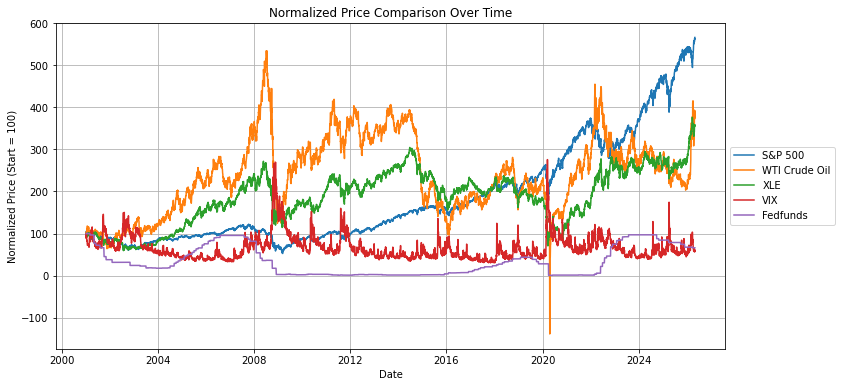

In [892]:
# This chart normalizes all assets to start at 100 so their long‑term performance
# can be compared on the same scale. It shows how equities (SP500, XLE) trend upward,
# oil (WTI) cycles with large booms and crashes, VIX stays low with crisis spikes,
# and Federal interest rates moves slowly in policy-driven steps. This provides a clear macro view
# of how each asset behaves over time relative to its own starting point, showing
# that most assets follow distinct long‑term patterns, with the S&P 500 and XLE
# displaying the most similar and stable trajectory.


plt.figure(figsize=(12, 6))

# Normalize all series to 100 at the start
df["SP500_Norm"] = df["Close"] / df["Close"].iloc[0] * 100
df["WTI_Norm"] = df["Close_WTI"] / df["Close_WTI"].iloc[0] * 100
df["XLE_Norm"] = df["Close_XLE"] / df["Close_XLE"].iloc[0] * 100
df["VIX_Norm"] = df["Close_VIX"] / df["Close_VIX"].iloc[0] * 100
df["Fedfunds_Norm"] = df["Close_Fedfunds"] / df["Close_Fedfunds"].iloc[0] * 100


# Plot all normalized series
plt.plot(df["Date"], df["SP500_Norm"], label="S&P 500")
plt.plot(df["Date"], df["WTI_Norm"], label="WTI Crude Oil")
plt.plot(df["Date"], df["XLE_Norm"], label="XLE")
plt.plot(df["Date"], df["VIX_Norm"], label="VIX")
plt.plot(df["Date"], df["Fedfunds_Norm"], label="Fedfunds")


plt.title("Normalized Price Comparison Over Time")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.grid(True)

#  Move legend outside the plot
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.show()




In [893]:
# This section computes a correlation matrix to measure how closely each asset
# moves with the others. This will help us better understand the relationships 
# between the variables and identifying whether assets like the S&P 500 and WTI 
# share meaningful co‑movement or are driven by different underlying factors.


# Compute daily percent returns
df["SP500_Return"] = df["Close"].pct_change()
df["WTI_Return"] = df["Close_WTI"].pct_change()
df["XLE_Return"] = df["Close_XLE"].pct_change()
df["VIX_Return"] = df["Close_VIX"].pct_change()
df["Fedfunds_Return"] = df["Close_Fedfunds"].pct_change()
  

# Select only the return columns
return_cols = [
    "SP500_Return",
    "WTI_Return",
    "XLE_Return",
    "VIX_Return",
    "Fedfunds_Return",
      
]

# Correlation matrix
corr_matrix = df[return_cols].corr()

print(corr_matrix)



                 SP500_Return  WTI_Return  XLE_Return  VIX_Return  \
SP500_Return         1.000000    0.135520    0.689696   -0.719688   
WTI_Return           0.135520    1.000000    0.295834   -0.109870   
XLE_Return           0.689696    0.295834    1.000000   -0.501671   
VIX_Return          -0.719688   -0.109870   -0.501671    1.000000   
Fedfunds_Return      0.022823    0.017572    0.044756   -0.013693   

                 Fedfunds_Return  
SP500_Return            0.022823  
WTI_Return              0.017572  
XLE_Return              0.044756  
VIX_Return             -0.013693  
Fedfunds_Return         1.000000  


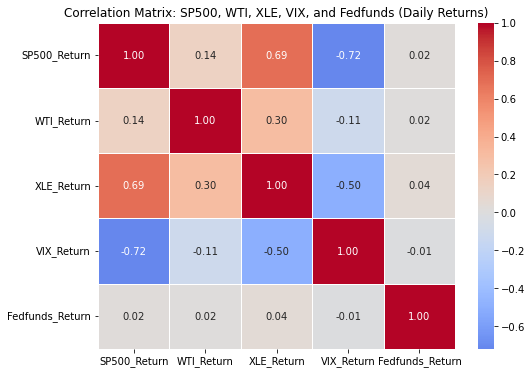

In [894]:
# Here we have a visual representation of the correlation matrix. We see a strong SP500–XLE relationships, 
# but surprisingly a weak connections between oil, interest rates,and VIX , highligthing a weak correlation 
# between these variables.

# Compute correlation matrix for returns
return_cols = ["SP500_Return", "WTI_Return", "XLE_Return", "VIX_Return","Fedfunds_Return"]
corr_matrix = df[return_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix: SP500, WTI, XLE, VIX, and Fedfunds (Daily Returns)")
plt.show()


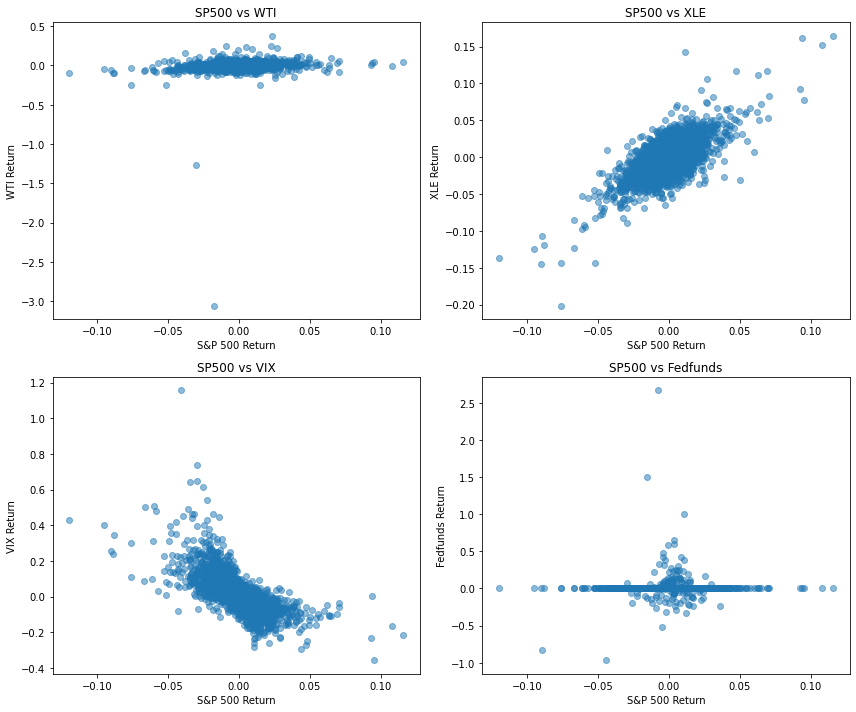

In [895]:
# This section we created a scatterplot which shows a strong SP500–XLE and SP500–VIX relationships, 
# a weak SP500–WTI link, and no daily connection between SP500 and FEDFUNDS
# Interestingly enough, the scatterplot appears stronger than the –0.72 correlation matrix suggests.
# I suspect that this is because the SP500–VIX relationship is non‑linear and driven by volatility spikes, 
# so the visual pattern looks tighter than what a linear correlation can capture. 


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# SP500 vs WTI
plt.subplot(2, 2, 1)
plt.scatter(df["SP500_Return"], df["WTI_Return"], alpha=0.5)
plt.xlabel("S&P 500 Return")
plt.ylabel("WTI Return")
plt.title("SP500 vs WTI")

# SP500 vs XLE 
plt.subplot(2, 2, 2)
plt.scatter(df["SP500_Return"], df["XLE_Return"], alpha=0.5)
plt.xlabel("S&P 500 Return")
plt.ylabel("XLE Return")
plt.title("SP500 vs XLE")

# SP500 vs VIX
plt.subplot(2, 2, 3)
plt.scatter(df["SP500_Return"], df["VIX_Return"], alpha=0.5)
plt.xlabel("S&P 500 Return")
plt.ylabel("VIX Return")
plt.title("SP500 vs VIX")

# SP500 vs FEDFUNDS 
plt.subplot(2, 2, 4)
plt.scatter(df["SP500_Return"], df["Fedfunds_Return"], alpha=0.5)
plt.xlabel("S&P 500 Return")
plt.ylabel("Fedfunds Return")
plt.title("SP500 vs Fedfunds")

plt.tight_layout()
plt.show()


In [896]:
# In this section we calculate daily returns for all assets and then compute their
# 30‑day rolling volatility. This helps reveal how quickly the S&P 500, WTI, VIX,
# and interest rates shift between calm and stressed market conditions. Tracking
# short‑term volatility allows us to see when different assets become more or less
# sensitive to macro shocks, which is essential for understanding how closely
# markets like the S&P 500 and WTI respond to the same underlying forces. By
# comparing their volatility patterns, we can assess whether these assets tend to
# react together, diverge, or move independently during periods of market stress.

# Returns
df["SP500_Return"] = df["Close"].pct_change()
df["WTI_Return"] = df["Close_WTI"].pct_change()
df["XLE_Return"] = df["Close_XLE"].pct_change()
df["VIX_Return"] = df["Close_VIX"].pct_change()
df["Fedfunds_Return"] = df["Close_Fedfunds"].pct_change()

# 30-day rolling volatility
window = 30

df["Vol_SP500_30d"] = df["SP500_Return"].rolling(window).std()
df["Vol_WTI_30d"] = df["WTI_Return"].rolling(window).std()
df["Vol_XLE_30d"] = df["XLE_Return"].rolling(window).std()
df["Vol_VIX_30d"] = df["VIX_Return"].rolling(window).std()
df["Vol_Fedfunds_30d"] = df["Fedfunds_Return"].rolling(window).std()


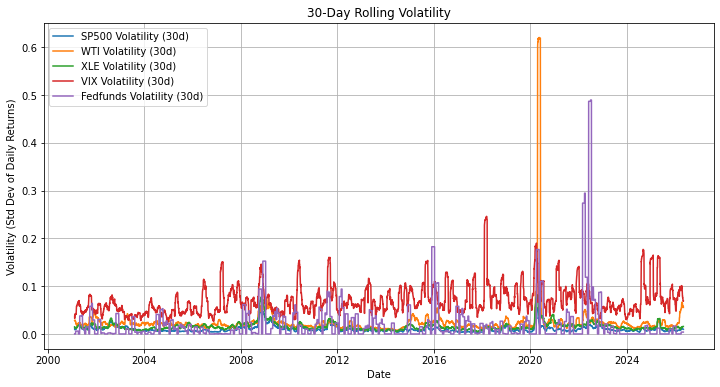

In [897]:
# This plot visualizes the 30‑day rolling volatility for all assets in the dataset.
# The chart shows how short‑term risk rises and falls across different assets,
# with huge spikes during crises like in 2020.
# It also shows that the S&P 500 and WTI often experience volatility at different
# magnitudes and times, indicating that they respond to different types of shocks
# rather than moving in a tightly linked pattern.
# When S&P 500 volatility is high but WTI volatility is not, it potentially means that the stock
# market is being driven by non‑oil factors, which could make oil not the source of the turbulence.



plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Vol_SP500_30d"], label="SP500 Volatility (30d)")
plt.plot(df["Date"], df["Vol_WTI_30d"], label="WTI Volatility (30d)")
plt.plot(df["Date"], df["Vol_XLE_30d"], label="XLE Volatility (30d)")
plt.plot(df["Date"], df["Vol_VIX_30d"], label="VIX Volatility (30d)")
plt.plot(df["Date"], df["Vol_Fedfunds_30d"], label="Fedfunds Volatility (30d)")

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev of Daily Returns)")
plt.legend()
plt.grid(True)
plt.show()


In [898]:
# This section we analyze the 1‑year rolling volatility for all assets in the dataset.
# Looking at volatility over a full year helps us see longer market cycles and
# whether assets like the S&P 500 and WTI tend to share the same extended periods
# of stress or move through their own separate risk patterns. This longer horizon
# gives useful context for understanding how closely (or loosely) the S&P 500 and
# WTI respond to broader macro forces over time.


# Returns
df["SP500_Return"] = df["Close"].pct_change()
df["WTI_Return"] = df["Close_WTI"].pct_change()
df["XLE_Return"] = df["Close_XLE"].pct_change()
df["VIX_Return"] = df["Close_VIX"].pct_change()
df["Fedfunds_Return"] = df["Close_Fedfunds"].pct_change()


# 1-year rolling volatility (≈ 252 trading days)
window = 252

df["Vol_SP500_1yr"] = df["SP500_Return"].rolling(window).std()
df["Vol_WTI_1yr"] = df["WTI_Return"].rolling(window).std()
df["Vol_XLE_1yr"] = df["XLE_Return"].rolling(window).std()
df["Vol_VIX_1yr"] = df["VIX_Return"].rolling(window).std()
df["Vol_Fedfunds_1yr"] = df["Fedfunds_Return"].rolling(window).std()



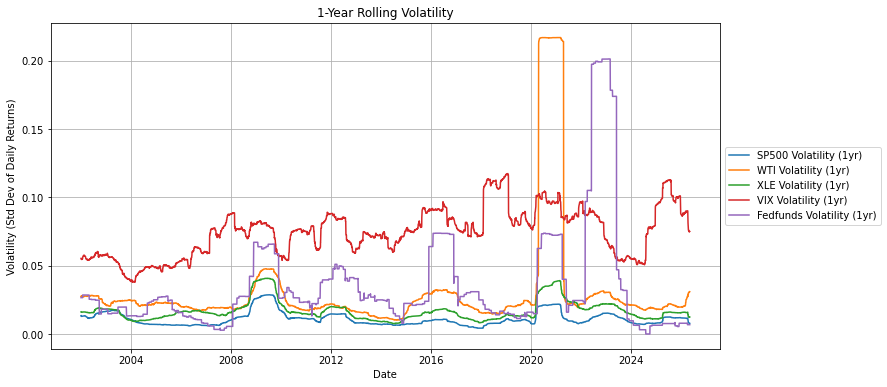

In [899]:
# This plot visualizes the 1-year rolling volatility for all assets in the dataset.
# This chart shows us on a long‑term view that the S&P 500 volatility often rises and falls
# independently of WTI volatility, potentially meaning that the stock market is frequently driven
# by non‑oil factors. This is because when S&P volatility spikes while WTI remains calm, it signals
# that market stress is coming from broader economic or financial conditions rather
# than from movements in oil prices.


plt.figure(figsize=(12, 6))

# 1-year rolling volatility (252 trading days)
plt.plot(df["Date"], df["Vol_SP500_1yr"], label="SP500 Volatility (1yr)", linewidth=1.5)
plt.plot(df["Date"], df["Vol_WTI_1yr"], label="WTI Volatility (1yr)", linewidth=1.5)
plt.plot(df["Date"], df["Vol_XLE_1yr"], label="XLE Volatility (1yr)", linewidth=1.5)
plt.plot(df["Date"], df["Vol_VIX_1yr"], label="VIX Volatility (1yr)", linewidth=1.5)
plt.plot(df["Date"], df["Vol_Fedfunds_1yr"], label="Fedfunds Volatility (1yr)", linewidth=1.5)


plt.title("1-Year Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev of Daily Returns)")

# Move legend outside so it doesn't block the chart
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.grid(True)

plt.show()


In [900]:
# The correlation analysis helps us understand how the S&P 500 and WTI move 
# relative to each other under normal market conditions. In this section we now 
# do event based analysis events, which can help us show how equities and oil often react to different 
# factors during geopolitical shocks, which can help us better understand their relationship.
# Daily returns appear small in these event windows because even during major shocks,
# financial assets typically move only a few percentage points per day, so the scale
# of daily return data naturally stays within a narrow range.
# We start with a function that extracts a ±30‑day event window 
# around key geopolitical shocks (9/11, the Russia‑Ukraine war, and the Iran conflict) 
# so we can analyze how markets behaved before and after each event. 
 
def event_window(df, event_date, window=30):
    event_date = pd.to_datetime(event_date)
    start = event_date - pd.Timedelta(days=window)
    end = event_date + pd.Timedelta(days=window)
    return df[(df["Date"] >= start) & (df["Date"] <= end)].copy()


In [901]:
# Here we extract 30‑day event windows around 9/11, the Russia‑Ukraine invasion, and the Iran conflict
# so we can analyze how markets behaved before and after each geopolitical shock.


win_911 = event_window(df, "2001-09-11", window=30)
win_ukraine = event_window(df, "2022-02-24", window=30)
win_iran = event_window(df, "2026-02-28", window=30)



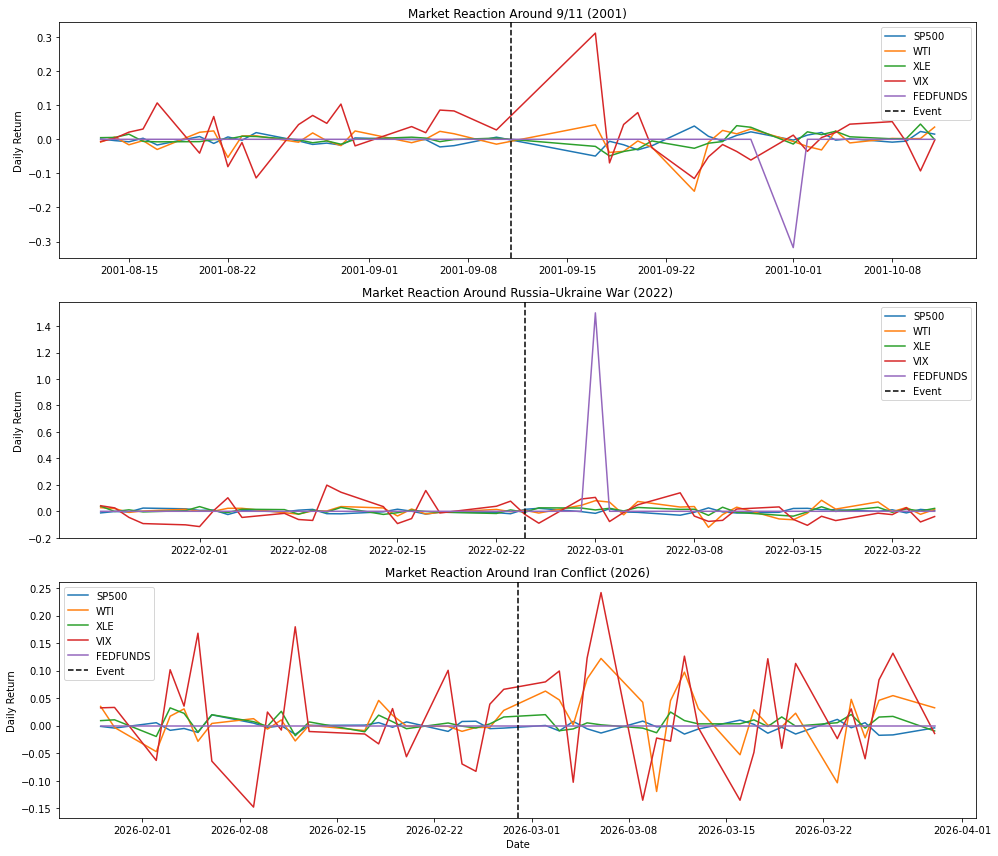

In [902]:
# Here we see a grapgh of the variables reacting before during and after these events.

# 9/11: VIX showed the largest spike, reflecting a sudden surge in uncertainty and fear 
# following the attacks. When markets reopened, the S&P 500 dropped sharply, while oil 
# prices increased sharply. Because oil moved higher at the same time equities fell,
# the pattern suggests that the equity decline was driven more by broad uncertainty than 
# by energy‑supply dynamics.
 


# Russia–Ukraine War: Federal interest rate volatility increased around the time of the 
# invasion as markets reassessed the outlook for monetary policy. The S&P 500 experienced 
# a modest decline during this period, while oil prices moved higher as traders priced in 
# a risk premium tied to potential supply disruptions. Because these assets reacted in 
# different ways, the pattern indicates that each market responded to a different aspect 
# of the shock rather than a single common driver.


# Iran Conflict: All assets showed elevated volatility during this period, as Middle‑East 
# tensions increased uncertainty around global oil supply and overall geopolitical stability. 
# The S&P 500 moved into a risk‑off pattern, while oil volatility rose more directly, reflecting 
# sensitivity to potential supply disruptions. The broad rise in volatility across multiple 
# assets suggests that this shock affected several parts of the financial system rather than 
# producing a single, uniform market reaction.


events = {
    "9/11 (2001)": ("2001-09-11", win_911),
    "Russia–Ukraine War (2022)": ("2022-02-24", win_ukraine),
    "Iran Conflict (2026)": ("2026-02-28", win_iran)
}

plt.figure(figsize=(14, 12))

for i, (title, (event_date, data)) in enumerate(events.items(), 1):
    plt.subplot(3, 1, i)
    
    plt.plot(data["Date"], data["SP500_Return"], label="SP500")
    plt.plot(data["Date"], data["WTI_Return"], label="WTI")
    plt.plot(data["Date"], data["XLE_Return"], label="XLE")
    plt.plot(data["Date"], data["VIX_Return"], label="VIX")
    plt.plot(data["Date"], data["Fedfunds_Return"], label="FEDFUNDS")
    
    # Clean, correct event marker
    plt.axvline(pd.to_datetime(event_date), color="black", linestyle="--", label="Event")
    
    plt.title(f"Market Reaction Around {title}")
    plt.ylabel("Daily Return")
    plt.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()



In [903]:
# Conclusion:
# This project brings together multiple layers of financial analysis—correlations,
# scatter plots, normalized price trends, rolling volatility, and event‑window
# studies—to build a complete picture of how major asset classes behave under both
# normal conditions and extreme geopolitical stress. The long‑term correlations and
# scatter plots reveal the structural relationships between equities, oil, energy
# stocks, volatility, and interest rates, while the rolling volatility analysis shows
# how market risk evolves across decades. The event‑window analysis then tests these
# relationships in real-world crisis environments such as 9/11, the Russia–Ukraine
# invasion, and the Iran conflict. Together, these components demonstrate that market
# dynamics are not static: correlations break, volatility surges, and sector behavior
# diverges sharply during shocks. By combining macro trends with crisis‑specific
# reactions, the project provides a deeper understanding of how interconnected—and
# fragile—financial markets can be when exposed to sudden global events. This holistic
# approach strengthens the overall analysis and highlights the importance of studying
# both long-term patterns and short-term disruptions to fully understand market behavior.
# Based on the results, WTI shows a weak direct impact on the S&P 500 at the
# daily frequency, indicating that oil affects a bit equity markets more through slower,
# macroeconomic channels rather than day‑to‑day price movements. This is consistent
# with the structure of the S&P 500, which is dominated by sectors such as
# technology, healthcare, and consumer services rather than oil‑dependent industries.
# As a result, fluctuations in oil prices have a limited immediate influence on the
# index’s long‑term behavior.

